# **Predicción de Consumo con Prophet**

## **Librerias**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
import holidays
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from sklearn.model_selection import ParameterGrid


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## **Carga de datos**

In [2]:

file_path = r"C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/consumo_electrico.csv"

df = pd.read_csv(file_path)  

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()

,casa_id,timestamp,consumo_kwh,coste_euros
0,1,2017-05-31 01:00:00,0.049,0.007286
1,1,2017-05-31 02:00:00,0.112,0.015633
2,1,2017-05-31 03:00:00,0.058,0.007817
3,1,2017-05-31 04:00:00,0.097,0.014200
4,1,2017-05-31 05:00:00,0.078,0.012555


## **Preprocesamiento**

In [3]:
#drop column called "coste_euros"
df = df.drop(columns=['coste_euros'])


In [4]:
df = df.dropna()

In [8]:
print(df.columns)


Index(['casa_id', 'timestamp', 'consumo_kwh'], dtype='object')


In [9]:
#filter consumption data positive
df = df[df['consumo_kwh'] > 0]

In [10]:
df_daily = df.groupby(df['timestamp'].dt.date).agg({'consumo_kwh': 'mean'}).reset_index()

In [11]:
df_daily.columns = ['ds', 'y']
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

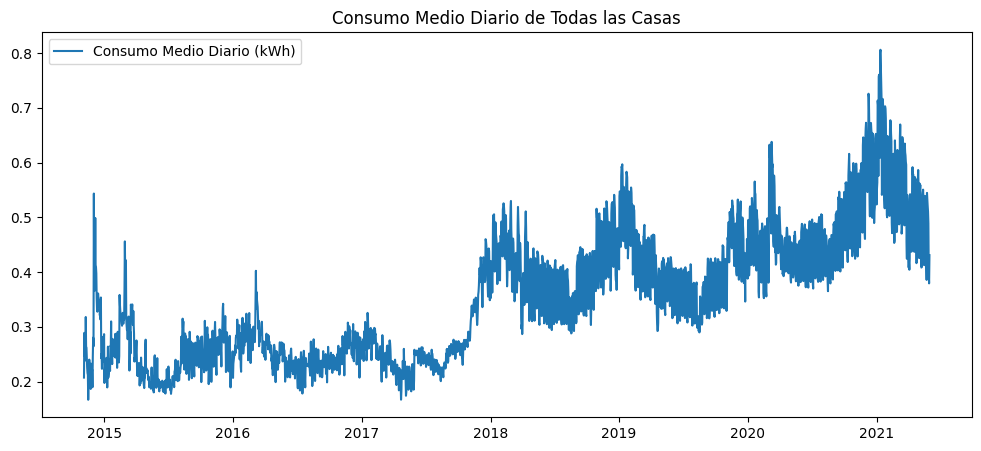

In [12]:
# Visualizar datos
plt.figure(figsize=(12,5))
plt.plot(df_daily['ds'], df_daily['y'], label='Consumo Medio Diario (kWh)')
plt.legend()
plt.title("Consumo Medio Diario de Todas las Casas")
plt.show()

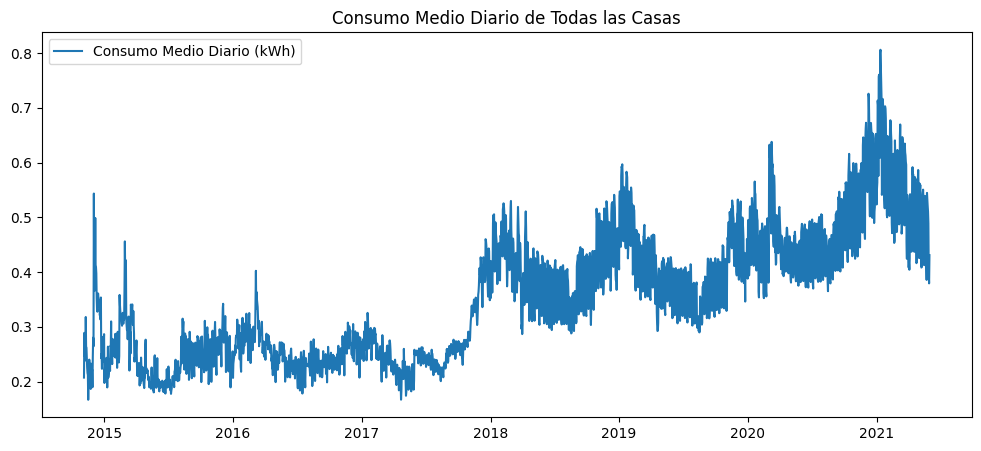

In [3]:
df = df.dropna()

df = df[df['consumo_kwh'] > 0]

df_daily = df.groupby(df['timestamp'].dt.date).agg({'consumo_kwh': 'mean'}).reset_index()

df_daily.columns = ['ds', 'y']
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

# Visualizar datos
plt.figure(figsize=(12,5))
plt.plot(df_daily['ds'], df_daily['y'], label='Consumo Medio Diario (kWh)')
plt.legend()
plt.title("Consumo Medio Diario de Todas las Casas")
plt.show()
    

In [13]:
print(df_daily.head())


          ds         y
0 2014-11-04  0.207522
1 2014-11-05  0.289225
2 2014-11-06  0.246208
3 2014-11-07  0.264819
4 2014-11-08  0.238821


## **Modelo Prophet con Tuning y Validación Cruzada**

In [ ]:
# Agregar festivos en España
es_holidays = holidays.Spain(years=range(df_daily['ds'].dt.year.min(), df_daily['ds'].dt.year.max()+1))
holidays_df = pd.DataFrame({'ds': list(es_holidays.keys()), 'holiday': 'public_holiday'})

# Definir espacio de búsqueda de hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
}

best_rmse = float('inf')
best_params = None
best_model = None

# Realizar tuning probando distintas combinaciones de hiperparámetros
for params in ParameterGrid(param_grid):
    model_tuned = Prophet(
        weekly_seasonality=True, 
        yearly_seasonality=True,
        holidays=holidays_df,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        holidays_prior_scale=params['holidays_prior_scale']
    )
    
    model_tuned.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model_tuned.fit(df_daily)

    # Validación cruzada
    df_cv = cross_validation(model_tuned, initial='365 days', period='30 days', horizon='7 days', parallel="processes")
    df_p = performance_metrics(df_cv)
    
    # Evaluar mejor modelo
    if df_p['rmse'].mean() < best_rmse:
        best_rmse = df_p['rmse'].mean()
        best_params = params
        best_model = model_tuned

# Predicción con el mejor modelo
future_best = best_model.make_future_dataframe(periods=30, freq='D')
forecast_best = best_model.predict(future_best)

# Mostrar mejores parámetros
print(f"🚀 Mejores parámetros encontrados: {best_params}")
print(f"📉 Mejor RMSE obtenido: {best_rmse:.4f}")
    

12:19:07 - cmdstanpy - INFO - Chain [1] start processing
12:19:07 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:19:12 - cmdstanpy - INFO - Chain [1] start processing
12:19:12 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:19:16 - cmdstanpy - INFO - Chain [1] start processing
12:19:16 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:19:20 - cmdstanpy - INFO - Chain [1] start processing
12:19:21 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
12:19:25 - cmdstanpy - INFO - Chain [1] start processing
12:19:25 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has per

🚀 Mejores parámetros encontrados: {'changepoint_prior_scale': 0.5, 'holidays_prior_scale': 1.0, 'seasonality_prior_scale': 0.1}
📉 Mejor RMSE obtenido: 0.0446


## **Evaluación del Modelo**

📌 **Métricas de Evaluación:**
🔹 MAE (Mean Absolute Error): 0.0333 (Error medio en kWh, idealmente bajo)
🔹 MSE (Mean Squared Error): 0.002043 (Penaliza errores grandes)
🔹 RMSE (Root Mean Squared Error): 0.0450 (Error típico esperado, cuanto menor mejor)
🔹 MAPE (Mean Absolute Percentage Error): 9.00% (Error porcentual, idealmente <10%)
🔹 Mediana del Error Absoluto: 6.92% (Mediana de errores en % para ver distribución)
🔹 Bias del Modelo: -0.0012 (Si es positivo, el modelo sobreestima; si es negativo, subestima)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


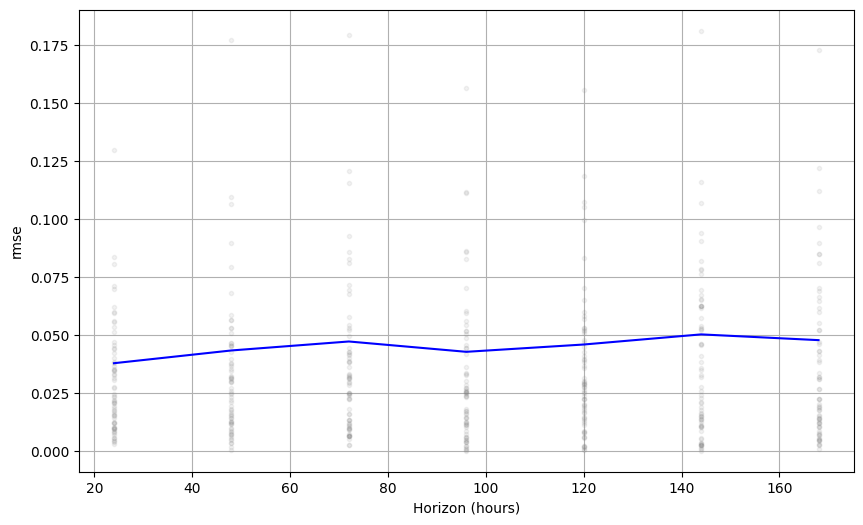

In [15]:

# Cálculo de métricas adicionales
mae = df_p['mae'].mean()
mse = df_p['mse'].mean()
rmse = df_p['rmse'].mean()
mape = df_p['mape'].mean()
median_abs_error = df_p['mdape'].mean()
bias = df_cv['yhat'].mean() - df_cv['y'].mean()


# Mostrar métricas
print("📌 **Métricas de Evaluación:**")
print(f"🔹 MAE (Mean Absolute Error): {mae:.4f} (Error medio en kWh, idealmente bajo)")
print(f"🔹 MSE (Mean Squared Error): {mse:.6f} (Penaliza errores grandes)")
print(f"🔹 RMSE (Root Mean Squared Error): {rmse:.4f} (Error típico esperado, cuanto menor mejor)")
print(f"🔹 MAPE (Mean Absolute Percentage Error): {mape:.2%} (Error porcentual, idealmente <10%)")
print(f"🔹 Mediana del Error Absoluto: {median_abs_error:.2%} (Mediana de errores en % para ver distribución)")
print(f"🔹 Bias del Modelo: {bias:.4f} (Si es positivo, el modelo sobreestima; si es negativo, subestima)")

# Visualización de métricas de validación
fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.show()
    

## **📈 Visualización de Resultados**

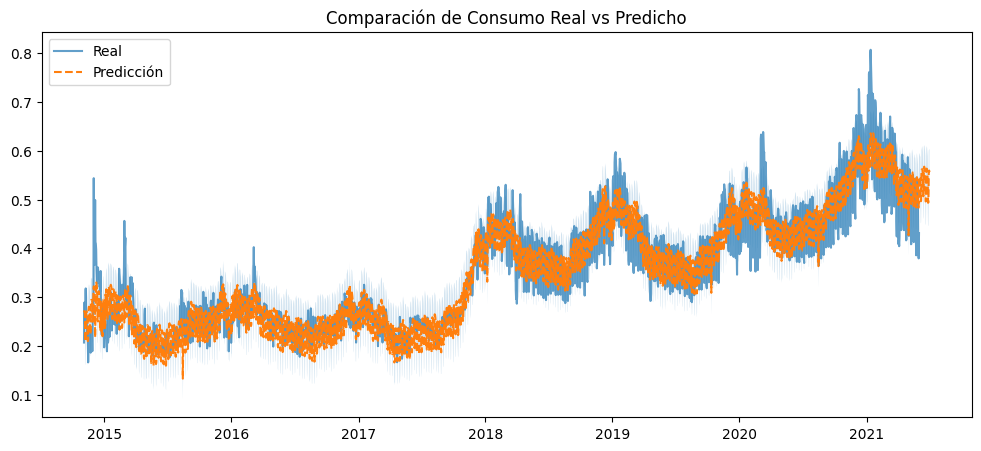

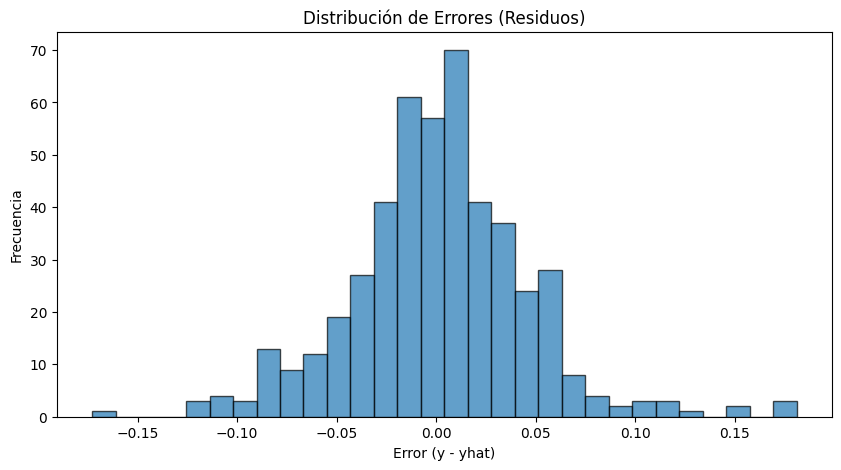

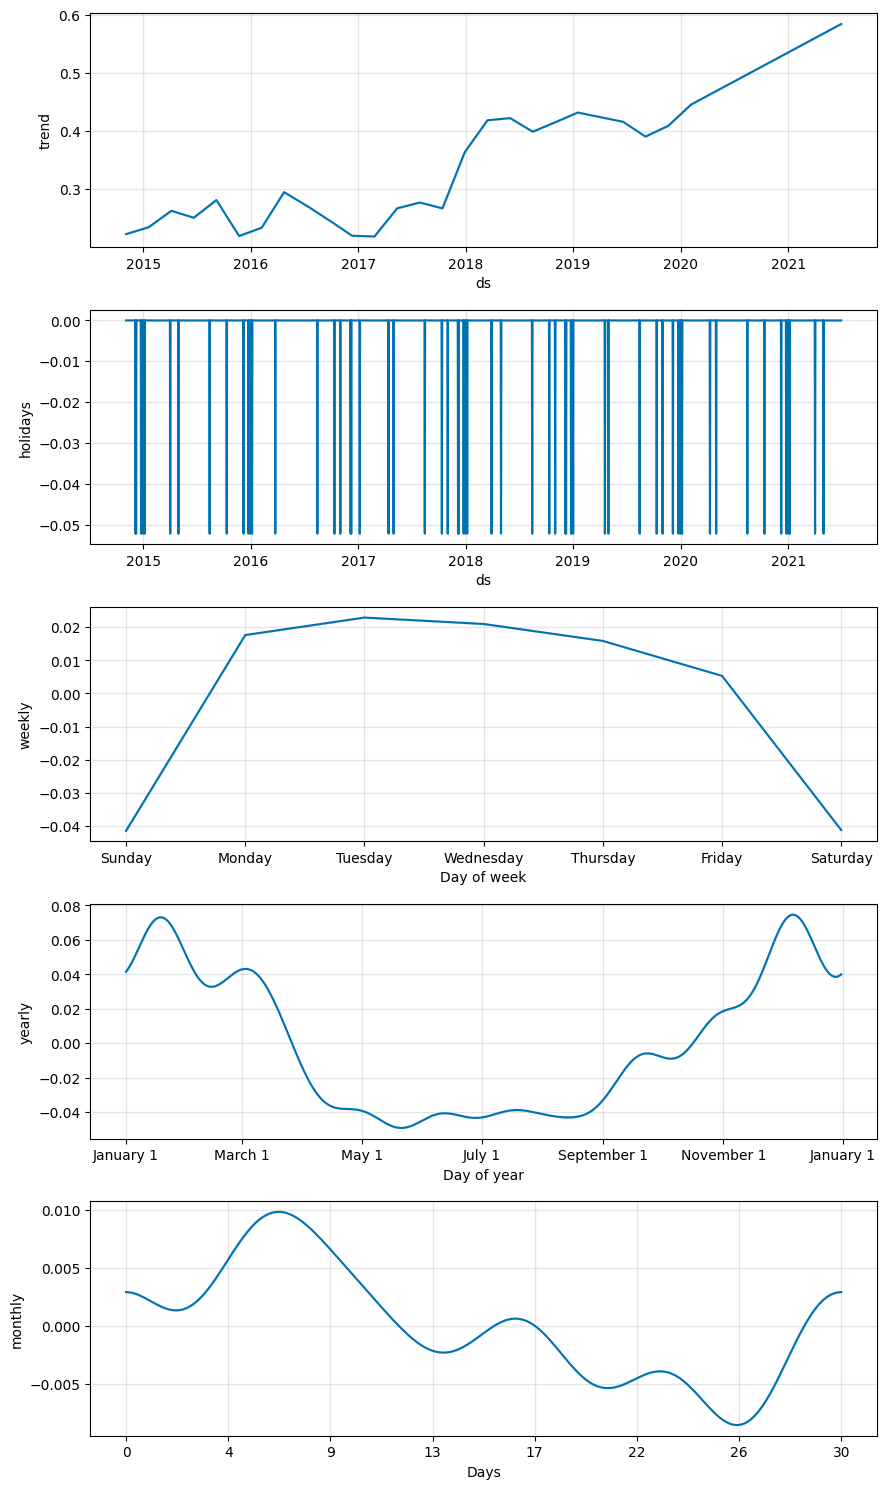

In [16]:

# Comparación entre valores reales y predichos
plt.figure(figsize=(12,5))
plt.plot(df_daily['ds'], df_daily['y'], label="Real", alpha=0.7)
plt.plot(forecast_best['ds'], forecast_best['yhat'], label="Predicción", linestyle="dashed")
plt.fill_between(forecast_best['ds'], forecast_best['yhat_lower'], forecast_best['yhat_upper'], alpha=0.2)
plt.legend()
plt.title("Comparación de Consumo Real vs Predicho")
plt.show()

# Gráfico de residuos
residuals = df_cv['y'] - df_cv['yhat']
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribución de Errores (Residuos)")
plt.xlabel("Error (y - yhat)")
plt.ylabel("Frecuencia")
plt.show()

# Componentes del modelo
best_model.plot_components(forecast_best)
plt.show()
    